In [1]:
#step 1 : IMPORTING THE LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots look clean
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', 50)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
#step 2: LOADING THE DATA

# Read all 3 CSV files from the data folder
sales = pd.read_csv('../data/sales_train_validation.csv')
calendar = pd.read_csv('../data/calendar.csv')
prices = pd.read_csv('../data/sell_prices.csv')

print("Sales shape:", sales.shape)
print("Calendar shape:", calendar.shape)
print("Prices shape:", prices.shape)

Sales shape: (30490, 1919)
Calendar shape: (1969, 14)
Prices shape: (6841121, 4)


In [3]:
#step 3: UNDERSTANDING EACH DATA FILE

sales.head(3)

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,...,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1


In [4]:
calendar.head(3)

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0


In [5]:
prices.head(3)

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26


In [6]:
#step 4: FILTERING DOWN THE DATA TO  CA_1 STORE, FOODS category {to simplify the data and focus only on one store and one particular food category}

# Keep only rows where store is CA_1 and category is FOODS
sales_ca1 = sales[(sales['store_id'] == 'CA_1') & (sales['cat_id'] == 'FOODS')]

# Reset the index so rows are numbered from 0 again
sales_ca1 = sales_ca1.reset_index(drop=True)

print("Filtered sales shape:", sales_ca1.shape)
print("Unique stores:", sales_ca1['store_id'].unique())
print("Unique categories:", sales_ca1['cat_id'].unique())

Filtered sales shape: (1437, 1919)
Unique stores: ['CA_1']
Unique categories: ['FOODS']


In [7]:
#step 5: Convert from Wide to Long format
# Melt the sales dataframe from wide to long format
sales_melted = sales_ca1.melt(
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    var_name='d',
    value_name='sales'
)

print("Melted shape:", sales_melted.shape)
sales_melted.head(5)

Melted shape: (2748981, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3
1,FOODS_1_002_CA_1_validation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0
2,FOODS_1_003_CA_1_validation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0
3,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1,0
4,FOODS_1_005_CA_1_validation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1,3


In [8]:
# step 6: Merging the data with Calendar 

# Merge sales with calendar on the 'd' column
sales_merged = sales_melted.merge(calendar, on='d', how='left')

print("After calendar merge shape:", sales_merged.shape)
sales_merged.head(5)

After calendar merge shape: (2748981, 21)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,FOODS_1_002_CA_1_validation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,FOODS_1_003_CA_1_validation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
4,FOODS_1_005_CA_1_validation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


In [9]:
#step 7: Merge with Prices

# Merge with prices on store_id, item_id and wm_yr_wk
sales_final = sales_merged.merge(prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

print("After prices merge shape:", sales_final.shape)
sales_final.head(3)

After prices merge shape: (2748981, 22)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.00
1,FOODS_1_002_CA_1_validation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,7.88
2,FOODS_1_003_CA_1_validation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.88


In [10]:
#step 8 : Final Cleanup
# Convert date column to proper datetime format
sales_final['date'] = pd.to_datetime(sales_final['date'])

# Sort by item and date so everything is in chronological order
sales_final = sales_final.sort_values(['item_id', 'date']).reset_index(drop=True)

# Check for missing values
print("Missing values per column:")
print(sales_final.isnull().sum())

Missing values per column:
id                    0
item_id               0
dept_id               0
cat_id                0
store_id              0
state_id              0
d                     0
sales                 0
date                  0
wm_yr_wk              0
weekday               0
wday                  0
month                 0
year                  0
event_name_1    2527683
event_type_1    2527683
event_name_2    2743233
event_type_2    2743233
snap_CA               0
snap_TX               0
snap_WI               0
sell_price       528976
dtype: int64


In [11]:
#step 10: Fix the missing values
# Fill missing event columns with 'No_Event'
sales_final['event_name_1'] = sales_final['event_name_1'].fillna('No_Event')
sales_final['event_type_1'] = sales_final['event_type_1'].fillna('No_Event')
sales_final['event_name_2'] = sales_final['event_name_2'].fillna('No_Event')
sales_final['event_type_2'] = sales_final['event_type_2'].fillna('No_Event')

# Fill missing prices with the median price for that item
sales_final['sell_price'] = sales_final.groupby('item_id')['sell_price'].transform(
    lambda x: x.fillna(x.median())
)

# Check if missing values are gone
print("Remaining missing values:")
print(sales_final.isnull().sum().sum())

Remaining missing values:
0


In [12]:
sales_final.head(10)

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,Saturday,1,1,2011,No_Event,No_Event,No_Event,No_Event,0,0,0,2.0
1,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,Sunday,2,1,2011,No_Event,No_Event,No_Event,No_Event,0,0,0,2.0
2,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,Monday,3,1,2011,No_Event,No_Event,No_Event,No_Event,0,0,0,2.0
3,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,Tuesday,4,2,2011,No_Event,No_Event,No_Event,No_Event,1,1,0,2.0
4,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,Wednesday,5,2,2011,No_Event,No_Event,No_Event,No_Event,1,0,1,2.0
5,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_6,2,2011-02-03,11101,Thursday,6,2,2011,No_Event,No_Event,No_Event,No_Event,1,1,1,2.0
6,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_7,0,2011-02-04,11101,Friday,7,2,2011,No_Event,No_Event,No_Event,No_Event,1,0,0,2.0
7,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_8,2,2011-02-05,11102,Saturday,1,2,2011,No_Event,No_Event,No_Event,No_Event,1,1,1,2.0
8,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_9,0,2011-02-06,11102,Sunday,2,2,2011,SuperBowl,Sporting,No_Event,No_Event,1,1,1,2.0
9,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_10,0,2011-02-07,11102,Monday,3,2,2011,No_Event,No_Event,No_Event,No_Event,1,1,0,2.0


In [13]:
#PHASE 2: EXPLORATORY DATA ANALYSIS
# What is EDA?
# Before building any model, we first explore the data visually. We make plots to find patterns, trends and anomalies. This is how real data scientists understand their data before touching any model.
# We'll answer these questions through plots:

# How have total food sales trended over 5 years?
# Are there weekly/monthly seasonal patterns?
# Which departments sell the most?
# Do holidays and SNAP days cause sales spikes?
# How does price affect sales?

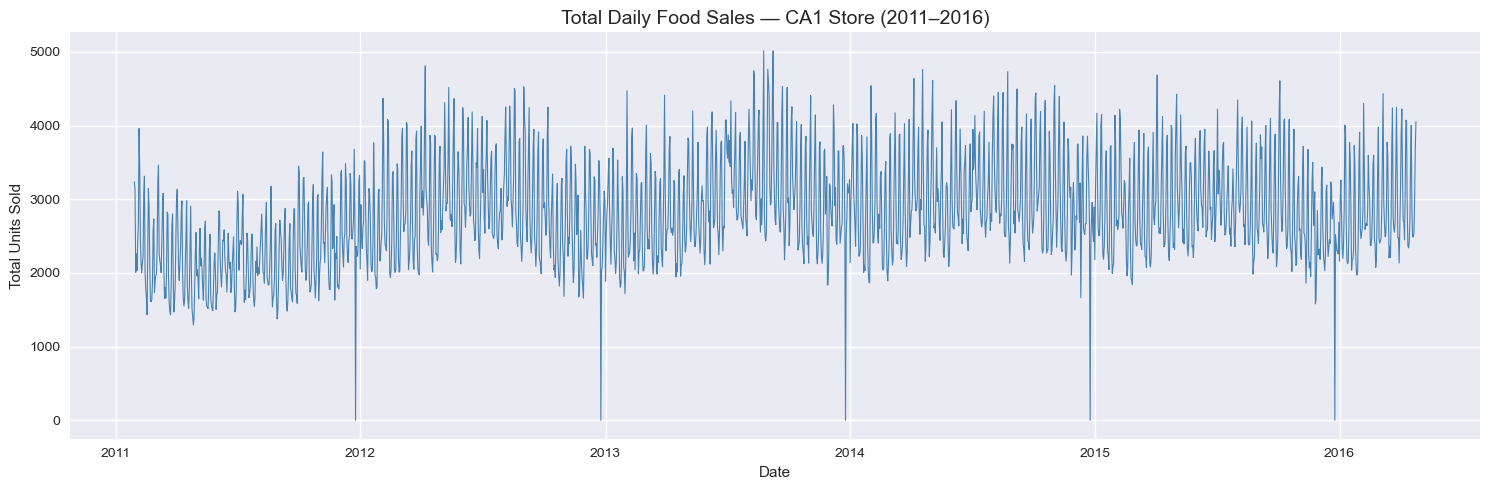

In [14]:
#2.1 Total Daily Sales Over Time

# Aggregate total sales across all food products per day
daily_sales = sales_final.groupby('date')['sales'].sum().reset_index()

# Plot
plt.figure(figsize=(15, 5))
plt.plot(daily_sales['date'], daily_sales['sales'], color='steelblue', linewidth=0.8)
plt.title('Total Daily Food Sales — CA1 Store (2011–2016)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.tight_layout()
plt.show()

In [15]:
# Reading the Chart
# 1. Overall Trend — Slightly Upward 📈
# From 2011 to 2016 the general level of sales has grown. In 2011 most days were between 1,500–3,000 units. By 2014–2016 most days are between 2,500–4,500 units. This tells us CA1 store grew its food sales over these 5 years.

# 2. The Jagged Pattern — Weekly Seasonality 📅
# The chart looks very jagged with regular up-down spikes repeating constantly. This is weekly seasonality — sales are higher on certain days of the week (likely weekends) and lower on others (likely Monday/Tuesday). This pattern repeats every single week for 5 years.

# 3. The Sharp Drops to Near Zero — Very Interesting ⚠️
# You can see a few sudden drops where sales crash to almost 0 — around late 2011, mid 2013, late 2014, and 2015. These are almost certainly days the store was closed — possibly Thanksgiving Day (many Walmart stores close) or other shutdowns. Our model needs to handle these carefully.

# 4. Peaks Around 5000 units
# A few times the line shoots up to nearly 5,000 units — well above normal. These are likely holiday periods like Christmas or SNAP payout days causing unusually high demand.

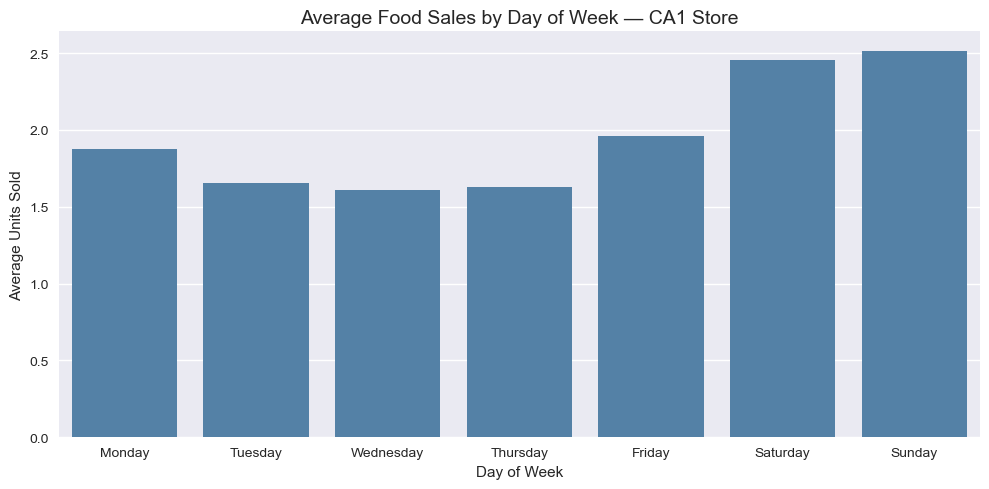

In [16]:
#2.2  Average Sales by Day of Week

# Calculate average sales per day of week
day_sales = sales_final.groupby('weekday')['sales'].mean().reset_index()

# Define correct order of days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales['weekday'] = pd.Categorical(day_sales['weekday'], categories=day_order, ordered=True)
day_sales = day_sales.sort_values('weekday')

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=day_sales, x='weekday', y='sales', color='steelblue')
plt.title('Average Food Sales by Day of Week — CA1 Store', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Average Units Sold')
plt.tight_layout()
plt.show()

In [17]:
# Reading the Chart
# Sunday is the highest — people do their weekly grocery shopping on Sundays. Families plan their week ahead and stock up.
# What you'd typically expect to see:

# 📈 Weekend (Saturday + Sunday) — highest sales, people are free to shop
# 📉 Monday + Tuesday — lowest sales, people just restocked over the weekend
# 📊 Friday — second peak, people shopping for the weekend



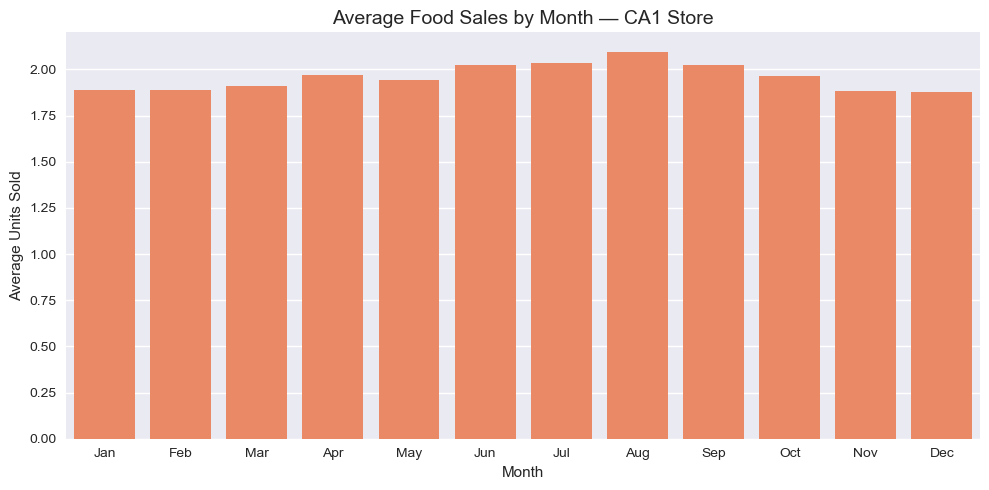

In [18]:
#2.3 Average Sales by Month

# Calculate average sales per month
month_sales = sales_final.groupby('month')['sales'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=month_sales, x='month', y='sales', color='coral')
plt.title('Average Food Sales by Month — CA1 Store', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Units Sold')
plt.xticks(ticks=range(12), labels=['Jan','Feb','Mar','Apr','May','Jun',
                                     'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

Key Observations
1. Sales build up from June through August
There is a clear and steady increase in sales starting from June, peaking in August. This represents the summer demand curve — driven by:

Summer gatherings, BBQs and outdoor parties
Families cooking more at home during summer holidays
Back to school shopping in August — families stocking up on food and snacks for the new school year

2. August is the absolute peak
August is the single highest month for average daily sales. The combination of late summer gatherings AND back to school season creates the strongest demand of the year.
3. Gradual decline from August through December
After August, sales steadily decrease month by month through the rest of the year. This is a strong and consistent pattern — as summer ends and routines normalize, food purchasing gradually slows down.
4. December is relatively low
Despite being a holiday month, December is on the lower end — likely because:

Store closures on Christmas pull the monthly average down
Holiday meal shopping is concentrated on just 1-2 specific days rather than the whole month

5. January and February are the lowest
Post-holiday slowdown is clearly visible at the start of the year before sales begin recovering toward summer.

Business Implication
This store follows a strong summer demand cycle — not a holiday cycle as commonly assumed in retail. The June → August ramp up is the most important seasonal pattern to capture. Our forecasting model must recognize this summer peak to avoid underestimating demand during those critical months.

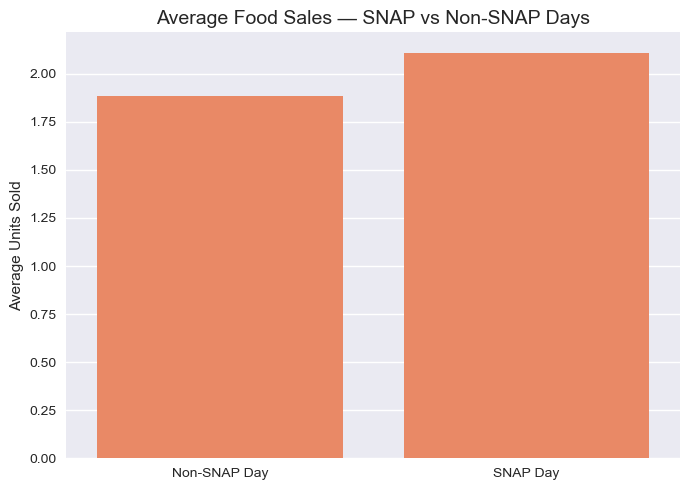

In [19]:
#2.3 Impact of SNAP Days on Sales

# Compare average sales on SNAP vs non-SNAP days
snap_sales = sales_final.groupby('snap_CA')['sales'].mean().reset_index()
snap_sales['snap_CA'] = snap_sales['snap_CA'].map({0: 'Non-SNAP Day', 1: 'SNAP Day'})

# Plot
plt.figure(figsize=(7, 5))
sns.barplot(data=snap_sales, x='snap_CA', y='sales', color='coral')
plt.title('Average Food Sales — SNAP vs Non-SNAP Days', fontsize=14)
plt.xlabel('')
plt.ylabel('Average Units Sold')
plt.tight_layout()
plt.show()

Key Observations
1. SNAP days drive higher food sales
SNAP payout days clearly result in higher average food sales compared to regular days. This makes direct sense — when low income households receive their food stamp benefits, they immediately go out and purchase groceries.
2. This is a reliable, predictable signal
Unlike holidays which vary year to year, SNAP payout days follow a fixed government schedule — they happen on the same dates every month, every year. This makes it an extremely reliable feature for our forecasting model.
3. This is unique to food retail
This SNAP effect would not appear in categories like electronics or hobbies — it's specific to food and grocery products. This is exactly why we chose the FOODS category for this project.

Business Implication:
SNAP payout days are a free, predictable demand signal that Walmart can use to plan staffing, inventory and restocking in advance. Our model will use snap_CA as a direct input feature — giving it the ability to anticipate these demand spikes automatically.

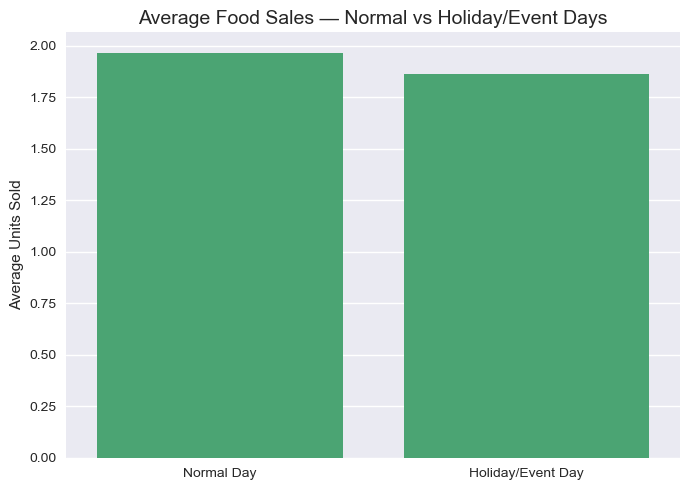

In [20]:
#2.4 Impact of Holidays on Sales

# Create a flag for event days vs normal days
sales_final['is_event'] = (sales_final['event_name_1'] != 'No_Event').astype(int)

# Compare average sales on event vs non event days
event_sales = sales_final.groupby('is_event')['sales'].mean().reset_index()
event_sales['is_event'] = event_sales['is_event'].map({0: 'Normal Day', 1: 'Holiday/Event Day'})

# Plot
plt.figure(figsize=(7, 5))
sns.barplot(data=event_sales, x='is_event', y='sales', color='mediumseagreen')
plt.title('Average Food Sales — Normal vs Holiday/Event Days', fontsize=14)
plt.xlabel('')
plt.ylabel('Average Units Sold')
plt.tight_layout()
plt.show()

Key Observations
1. Normal days surprisingly outsell event days on average
Despite expectations, regular days record higher average food sales than holiday or event days. This is counterintuitive but explainable.
2. Store closures drag the holiday average down
Major holidays like Thanksgiving and Christmas — when the store is fully or partially closed — are classified as event days but record near-zero sales. This pulls the overall event day average significantly downward.
3. Not all events drive food demand equally
Sporting events, cultural celebrations and religious observances all fall under "event days" but have very different impacts on food sales. Averaging them all together masks the real story.
4. Specific events matter more than the general event flag
The real holiday signal lives at the individual event level — Super Bowl drives snack sales, Thanksgiving eve drives cooking ingredient sales. Our model will use specific event names as features, not just a generic 0/1 event flag.

Business Implication:
Holiday planning in retail cannot be one-size-fits-all. Each event type needs to be treated differently — some drive demand up, some cause store closures that drop sales to zero. Our forecasting model handles this by using specific event name features rather than a simple holiday flag.

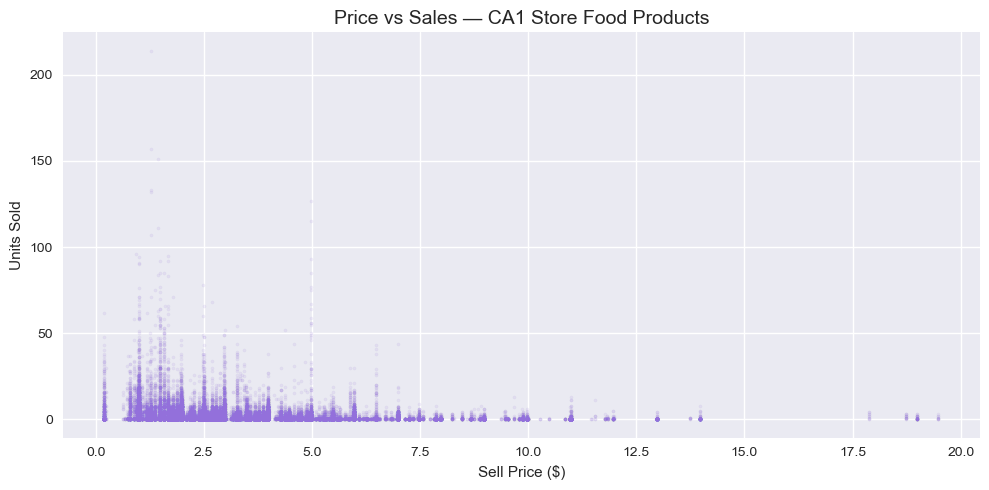

In [21]:
#2.5 Price vs Sales Relationship

# Sample 50,000 rows to keep the plot manageable
sample = sales_final[sales_final['sell_price'].notna()].sample(50000, random_state=42)

# Plot
plt.figure(figsize=(10, 5))
plt.scatter(sample['sell_price'], sample['sales'], alpha=0.1, color='mediumpurple', s=5)
plt.title('Price vs Sales — CA1 Store Food Products', fontsize=14)
plt.xlabel('Sell Price ($)')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

Insight from the Price vs Sales Scatter Plot

The scatter plot indicates a clear inverse relationship between product price and units sold for food items in the CA1 store. Most high-sales observations are concentrated in the lower price range (approximately $0–$5), while products with higher prices generally exhibit significantly lower sales volumes. This suggests that demand for food products is highly price-sensitive, where customers tend to purchase larger quantities of lower-priced items.

The visualization also reveals that sales distribution is highly skewed. While the majority of observations correspond to low daily sales, a few low-priced products experience extreme demand spikes exceeding 100–200 units sold. These spikes likely correspond to highly popular staples, promotional campaigns, holiday effects, or SNAP benefit periods, indicating that external business factors strongly influence retail demand patterns.

Another notable observation is the presence of vertical clusters at specific price points such as $0.99, $1.99, and $2.49. This reflects standard retail pricing strategies where products are sold at fixed pricing tiers rather than continuously varying prices.

Additionally, higher-priced products ($10+) show sparse demand with very few units sold per day, implying that premium food items have lower purchase frequency and contribute less to overall sales volume.

Overall, the plot demonstrates that selling price is an important predictive feature for demand forecasting. The observed price-demand relationship justifies incorporating price-related variables, promotional indicators, lag features, and event-based signals into machine learning models such as LightGBM to improve forecast accuracy.

In [22]:
# PHASE 3: FEATURE ENGINEERING

# What is Feature Engineering?
# Right now our dataset has basic columns like date, sales, price, snap_CA. But raw columns alone aren't enough for a model to make accurate predictions.
# Feature engineering means creating new columns from existing ones that give the model more signal to learn from.
# Think of it like this — instead of just telling the model "this is day d_500", we tell it:

# This day was a Sunday
# Sales 7 days ago were 350 units
# The average sales over the last 28 days was 310 units
# The price dropped by $0.50 this week
# It was a SNAP payout day

# The more useful signals we give, the better the model predicts.

In [23]:
#3.1 Create a Single Product Dataset for Feature Engineering

# Pick one product to work with
product_id = 'FOODS_3_090_CA_1_validation'

# Filter to just that one product
product_df = sales_final[sales_final['id'] == product_id].copy()

# Sort by date
product_df = product_df.sort_values('date').reset_index(drop=True)

print("Product dataframe shape:", product_df.shape)
print("Date range:", product_df['date'].min(), "to", product_df['date'].max())
product_df[['date', 'sales', 'sell_price', 'snap_CA']].head(10)

Product dataframe shape: (1913, 23)
Date range: 2011-01-29 00:00:00 to 2016-04-24 00:00:00


,date,sales,sell_price,snap_CA
0,2011-01-29,107,1.25,0
1,2011-01-30,182,1.25,0
2,2011-01-31,47,1.25,0
3,2011-02-01,47,1.25,1
4,2011-02-02,62,1.25,1
5,2011-02-03,90,1.25,1
6,2011-02-04,81,1.25,1
7,2011-02-05,124,1.25,1
8,2011-02-06,134,1.25,1
9,2011-02-07,65,1.25,1


In [24]:
#3.2 Time Based Features
# Extract time based features from the date column
product_df['day_of_week'] = product_df['date'].dt.dayofweek      # 0=Monday, 6=Sunday
product_df['day_of_month'] = product_df['date'].dt.day            # 1-31
product_df['week_of_year'] = product_df['date'].dt.isocalendar().week.astype(int)  # 1-52
product_df['month'] = product_df['date'].dt.month                 # 1-12
product_df['year'] = product_df['date'].dt.year                   # 2011-2016
product_df['is_weekend'] = (product_df['day_of_week'] >= 5).astype(int)  # 1 if Sat/Sun

# Check
product_df[['date', 'day_of_week', 'day_of_month', 'week_of_year', 'month', 'year', 'is_weekend']].head(7)

,date,day_of_week,day_of_month,week_of_year,month,year,is_weekend
0,2011-01-29,5,29,4,1,2011,1
1,2011-01-30,6,30,4,1,2011,1
2,2011-01-31,0,31,5,1,2011,0
3,2011-02-01,1,1,5,2,2011,0
4,2011-02-02,2,2,5,2,2011,0
5,2011-02-03,3,3,5,2,2011,0
6,2011-02-04,4,4,5,2,2011,0


In [25]:
#3.3 Lag Features

# Create lag features

product_df['lag_7'] = product_df['sales'].shift(7)    # sales 7 days ago
product_df['lag_28'] = product_df['sales'].shift(28)  # sales 28 days ago

# Check
product_df[['date', 'sales', 'lag_7', 'lag_28']].head(35)

,date,sales,lag_7,lag_28
0,2011-01-29,107,NaN,NaN
1,2011-01-30,182,NaN,NaN
2,2011-01-31,47,NaN,NaN
3,2011-02-01,47,NaN,NaN
4,2011-02-02,62,NaN,NaN
5,2011-02-03,90,NaN,NaN
6,2011-02-04,81,NaN,NaN
7,2011-02-05,124,107.0,NaN
8,2011-02-06,134,182.0,NaN
9,2011-02-07,65,47.0,NaN


In [26]:
# 3.4 Rolling Statistics

# Create rolling features
product_df['rolling_mean_7'] = product_df['sales'].shift(1).rolling(window=7).mean()
product_df['rolling_mean_28'] = product_df['sales'].shift(1).rolling(window=28).mean()
product_df['rolling_std_7'] = product_df['sales'].shift(1).rolling(window=7).std()

# Check
product_df[['date', 'sales', 'rolling_mean_7', 'rolling_mean_28', 'rolling_std_7']].head(35)

,date,sales,rolling_mean_7,rolling_mean_28,rolling_std_7
0,2011-01-29,107,NaN,NaN,NaN
1,2011-01-30,182,NaN,NaN,NaN
2,2011-01-31,47,NaN,NaN,NaN
3,2011-02-01,47,NaN,NaN,NaN
4,2011-02-02,62,NaN,NaN,NaN
5,2011-02-03,90,NaN,NaN,NaN
6,2011-02-04,81,NaN,NaN,NaN
7,2011-02-05,124,88.000000,NaN,47.060245
8,2011-02-06,134,90.428571,NaN,48.617065
9,2011-02-07,65,83.571429,NaN,35.037395


In [27]:
#3.5 Price Features
# Calculate price change from last week
product_df['price_change'] = product_df['sell_price'].diff(7)

# Calculate price change percentage
product_df['price_change_pct'] = product_df['sell_price'].pct_change(7) * 100

# Check
product_df[['date', 'sell_price', 'price_change', 'price_change_pct']].head(35)

,date,sell_price,price_change,price_change_pct
0,2011-01-29,1.25,NaN,NaN
1,2011-01-30,1.25,NaN,NaN
2,2011-01-31,1.25,NaN,NaN
3,2011-02-01,1.25,NaN,NaN
4,2011-02-02,1.25,NaN,NaN
5,2011-02-03,1.25,NaN,NaN
6,2011-02-04,1.25,NaN,NaN
7,2011-02-05,1.25,0.0,0.0
8,2011-02-06,1.25,0.0,0.0
9,2011-02-07,1.25,0.0,0.0


In [28]:
#3.6 Event Features
# Create event features
product_df['is_event'] = (product_df['event_name_1'] != 'No_Event').astype(int)
product_df['is_snap'] = product_df['snap_CA'].astype(int)

# Encode specific high impact events
product_df['is_superbowl'] = (product_df['event_name_1'] == 'SuperBowl').astype(int)
product_df['is_thanksgiving'] = (product_df['event_name_1'] == 'Thanksgiving').astype(int)
product_df['is_christmas'] = (product_df['event_name_1'] == 'Christmas').astype(int)
product_df['is_easter'] = (product_df['event_name_1'] == 'Easter').astype(int)

# Check
product_df[['date', 'event_name_1', 'is_event', 'is_snap', 
            'is_superbowl', 'is_thanksgiving', 'is_christmas']].head(50)

,date,event_name_1,is_event,is_snap,is_superbowl,is_thanksgiving,is_christmas
0,2011-01-29,No_Event,0,0,0,0,0
1,2011-01-30,No_Event,0,0,0,0,0
2,2011-01-31,No_Event,0,0,0,0,0
3,2011-02-01,No_Event,0,1,0,0,0
4,2011-02-02,No_Event,0,1,0,0,0
5,2011-02-03,No_Event,0,1,0,0,0
6,2011-02-04,No_Event,0,1,0,0,0
7,2011-02-05,No_Event,0,1,0,0,0
8,2011-02-06,SuperBowl,1,1,1,0,0
9,2011-02-07,No_Event,0,1,0,0,0


In [29]:
# Check if specific events exist in our product dataframe
print("SuperBowl days:", product_df['is_superbowl'].sum())
print("Thanksgiving days:", product_df['is_thanksgiving'].sum())
print("Christmas days:", product_df['is_christmas'].sum())
print("Easter days:", product_df['is_easter'].sum())
print("Total event days:", product_df['is_event'].sum())
print("Total SNAP days:", product_df['is_snap'].sum())

SuperBowl days: 6
Thanksgiving days: 5
Christmas days: 5
Easter days: 5
Total event days: 154
Total SNAP days: 630


In [30]:
#3.7 Check Final Feature Set

# List all feature columns
feature_cols = ['day_of_week', 'day_of_month', 'week_of_year', 'month', 'year',
                'is_weekend', 'lag_7', 'lag_28', 'rolling_mean_7', 
                'rolling_mean_28', 'rolling_std_7', 'price_change', 
                'price_change_pct', 'is_event', 'is_snap', 'is_superbowl',
                'is_thanksgiving', 'is_christmas', 'is_easter']

print("Total features:", len(feature_cols))
print("\nFirst few rows with all features:")
product_df[['date', 'sales'] + feature_cols].head(35)

Total features: 19

First few rows with all features:


,date,sales,day_of_week,day_of_month,week_of_year,month,year,is_weekend,lag_7,lag_28,rolling_mean_7,rolling_mean_28,rolling_std_7,price_change,price_change_pct,is_event,is_snap,is_superbowl,is_thanksgiving,is_christmas,is_easter
0,2011-01-29,107,5,29,4,1,2011,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0
1,2011-01-30,182,6,30,4,1,2011,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0
2,2011-01-31,47,0,31,5,1,2011,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0
3,2011-02-01,47,1,1,5,2,2011,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,0,0,0
4,2011-02-02,62,2,2,5,2,2011,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,0,0,0
5,2011-02-03,90,3,3,5,2,2011,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,0,0,0
6,2011-02-04,81,4,4,5,2,2011,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,0,0,0
7,2011-02-05,124,5,5,5,2,2011,1,107.0,NaN,88.000000,NaN,47.060245,0.0,0.0,0,1,0,0,0,0
8,2011-02-06,134,6,6,5,2,2011,1,182.0,NaN,90.428571,NaN,48.617065,0.0,0.0,1,1,1,0,0,0
9,2011-02-07,65,0,7,6,2,2011,0,47.0,NaN,83.571429,NaN,35.037395,0.0,0.0,0,1,0,0,0,0


In [31]:
#3.8 Dropping NaN features
# Drop rows with NaN values created by lag and rolling features
product_df_clean = product_df.dropna(subset=feature_cols).reset_index(drop=True)

print("Before dropping NaN:", product_df.shape)
print("After dropping NaN:", product_df_clean.shape)
print("Rows dropped:", product_df.shape[0] - product_df_clean.shape[0])

Before dropping NaN: (1913, 39)
After dropping NaN: (1885, 39)
Rows dropped: 28


Phase 4 — Modeling
In this phase we build and train three different forecasting models on our cleaned and feature engineered dataset. The goal is to predict daily food sales for product FOODS_3_090 at Walmart's CA1 store and compare how well each model performs.
Why Three Models?
We build three models from different families rather than just one — because each approaches the forecasting problem differently:

LightGBM — a powerful machine learning model that uses all 19 of our engineered features to find complex patterns in the data. This is the most sophisticated model and typically the most accurate.
Prophet — a forecasting tool built by Meta specifically for business time series. It handles trends, weekly seasonality and holidays automatically without needing manual feature engineering.
SARIMA — a classical statistical model that uses only past sales values to predict future ones. It serves as our baseline — if our advanced models can't beat SARIMA, something is wrong.

How We Evaluate
We split the data chronologically:

Training set — 2011 to 2015 — the model learns from this
Test set — 2016 — the model predicts this and we compare against real values

We never shuffle the data — time order must always be respected in time series forecasting.
Evaluation Metric
We use MAE (Mean Absolute Error) — on average, how many units off is our prediction? Simple, interpretable, and easy to explain to any stakeholder.

In [32]:
#Phase 4: Modeling 

#4.1 Train Test Split

# Split data chronologically
# Train on everything before 2016, test on 2016
train = product_df_clean[product_df_clean['year'] < 2016].copy()
test = product_df_clean[product_df_clean['year'] >= 2016].copy()

print("Train set:", train.shape)
print("Train date range:", train['date'].min(), "to", train['date'].max())
print("\nTest set:", test.shape)
print("Test date range:", test['date'].min(), "to", test['date'].max())

Train set: (1770, 39)
Train date range: 2011-02-26 00:00:00 to 2015-12-31 00:00:00

Test set: (115, 39)
Test date range: 2016-01-01 00:00:00 to 2016-04-24 00:00:00


In [33]:
#4.2 Importing LightGBM module

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("LightGBM version:", lgb.__version__)

LightGBM version: 4.6.0


In [34]:
#4.3 Prepare Data for LightGBM

# Define feature columns and target
feature_cols = ['day_of_week', 'day_of_month', 'week_of_year', 'month', 'year',
                'is_weekend', 'lag_7', 'lag_28', 'rolling_mean_7', 
                'rolling_mean_28', 'rolling_std_7', 'price_change', 
                'price_change_pct', 'is_event', 'is_snap', 'is_superbowl',
                'is_thanksgiving', 'is_christmas', 'is_easter']

# Separate features and target for train and test
X_train = train[feature_cols]
y_train = train['sales']

X_test = test[feature_cols]
y_test = test['sales']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1770, 19)
X_test shape: (115, 19)
y_train shape: (1770,)
y_test shape: (115,)


In [35]:
#4.4 Train LightGBM Model
# Define model parameters
params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'min_child_samples': 20,
    'verbose': -1
}

# Create LightGBM datasets
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

# Train the model
model_lgb = lgb.train(
    params,
    lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_val],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

print("Model training complete!")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 15.6683
Early stopping, best iteration is:
[86]	valid_0's l1: 15.6632
Model training complete!


In [36]:
#4.5 Make Predictions
# Generate predictions on test set
lgb_predictions = model_lgb.predict(X_test)

# Calculate MAE
lgb_mae = mean_absolute_error(y_test, lgb_predictions)

print("LightGBM MAE:", round(lgb_mae, 2))
print("This means on average our predictions are off by", round(lgb_mae, 2), "units per day")

LightGBM MAE: 15.66
This means on average our predictions are off by 15.66 units per day


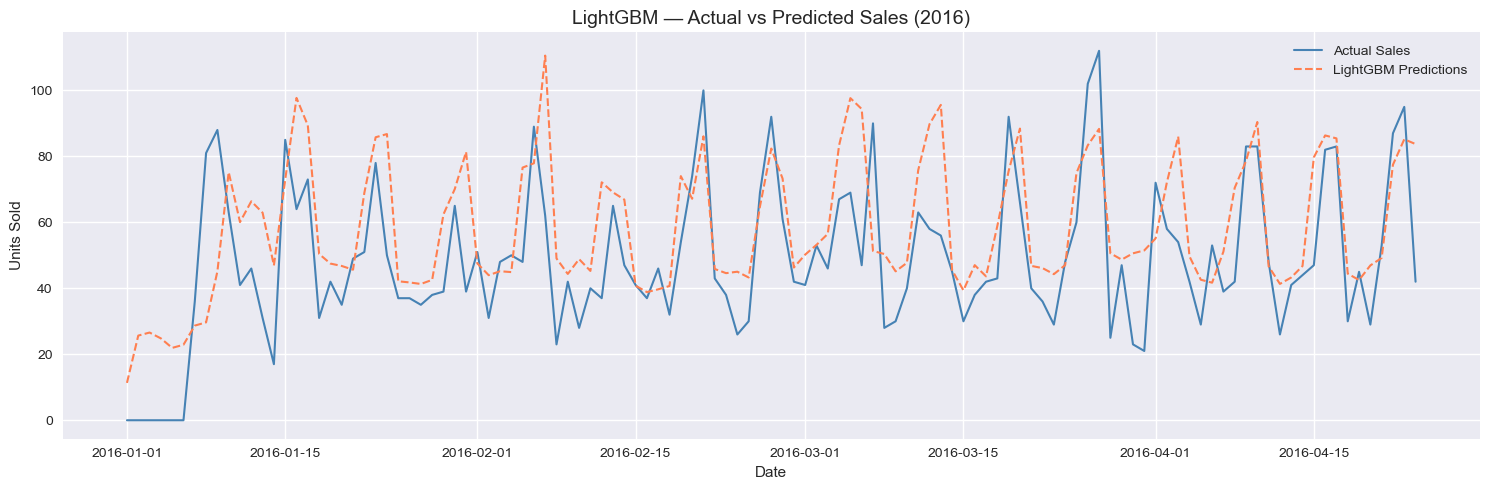

In [37]:
#4.6 Visualize LightGBM Predictions

plt.figure(figsize=(15, 5))

# Plot actual sales
plt.plot(test['date'].values, y_test.values, 
         color='steelblue', label='Actual Sales', linewidth=1.5)

# Plot predicted sales
plt.plot(test['date'].values, lgb_predictions, 
         color='coral', label='LightGBM Predictions', 
         linewidth=1.5, linestyle='--')

plt.title('LightGBM — Actual vs Predicted Sales (2016)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

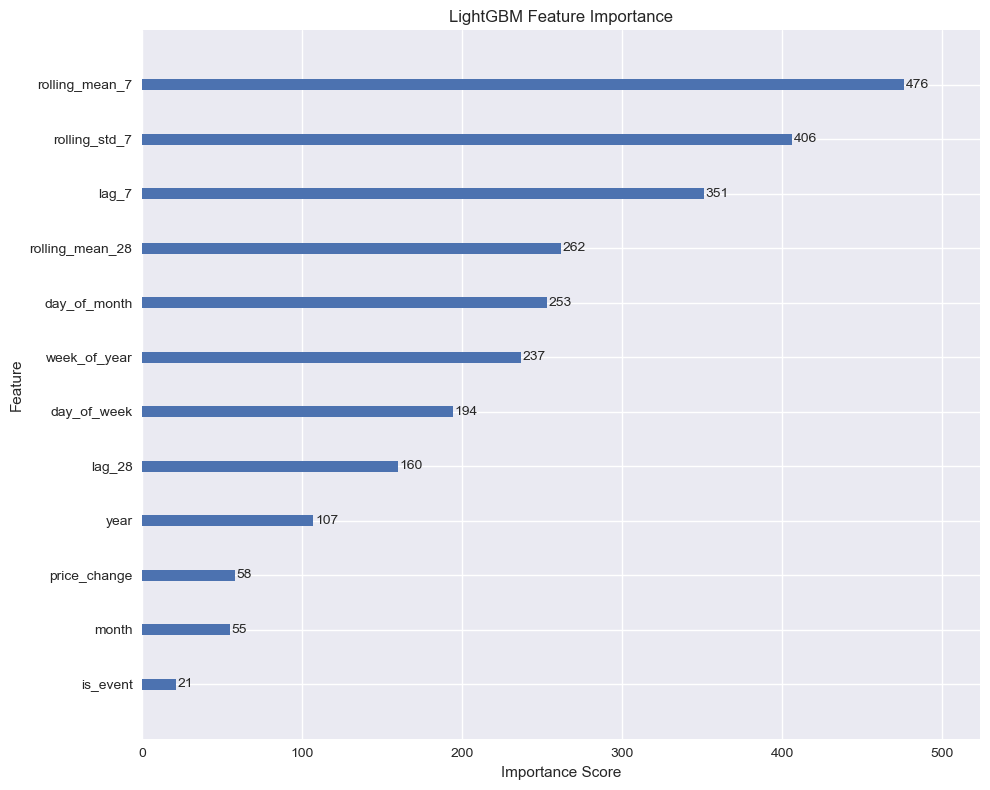

In [38]:
#4.7 Feature Importance
# Plot feature importance
lgb.plot_importance(model_lgb, figsize=(10, 8), 
                    title='LightGBM Feature Importance',
                    xlabel='Importance Score',
                    ylabel='Feature')
plt.tight_layout()
plt.show()

In [39]:
# "Our feature importance analysis confirmed that recent sales history — specifically the 7 day rolling mean and lag features — are the strongest predictors of future demand. This aligns with the time series principle that recent patterns are the best predictors of near future behavior."

In [40]:
#B. Prophet Model

# What is Prophet?
# Prophet is a forecasting tool built by Meta (Facebook) and released as open source in 2017. It was designed specifically for business time series — things like daily sales, website traffic, app usage etc.
# What makes it special:

# It doesn't need manual feature engineering like LightGBM
# It automatically detects trend, weekly seasonality and yearly seasonality
# You can simply tell it "these are the holidays" and it handles them automatically
# It's extremely easy to use — just 3-4 lines of code to get a forecast

In [41]:
# B. Prophet model

#4.1B Import Prophet

from prophet import Prophet
print("Prophet imported successfully!")

Prophet imported successfully!


In [42]:
#4.2 Prepare Data for Prophet
# Prophet requires columns to be named 'ds' and 'y'
# ds = datestamp, y = target variable
train_prophet = train[['date', 'sales']].rename(columns={'date': 'ds', 'y': 'sales', 'sales': 'y'})
test_prophet = test[['date', 'sales']].rename(columns={'date': 'ds', 'y': 'sales', 'sales': 'y'})

print("Train Prophet shape:", train_prophet.shape)
print("Test Prophet shape:", test_prophet.shape)
train_prophet.head(3)

Train Prophet shape: (1770, 2)
Test Prophet shape: (115, 2)


,ds,y
0,2011-02-26,0
1,2011-02-27,0
2,2011-02-28,0


In [43]:
#4.3  Train Prophet Model

# Create and train Prophet model
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

# Fit the model on training data
model_prophet.fit(train_prophet)

print("Prophet model training complete!")

10:48:29 - cmdstanpy - INFO - Chain [1] start processing
10:48:29 - cmdstanpy - INFO - Chain [1] done processing


Prophet model training complete!


In [44]:
#4.4 Make Predictions with Prophet

# Create a dataframe with future dates to predict
future = model_prophet.make_future_dataframe(periods=115)

# Generate predictions
forecast = model_prophet.predict(future)

# Extract just the test period predictions
prophet_predictions = forecast['yhat'].tail(115).values

# Calculate MAE
prophet_mae = mean_absolute_error(y_test, prophet_predictions)

print("Prophet MAE:", round(prophet_mae, 2))
print("This means on average our predictions are off by", round(prophet_mae, 2), "units per day")

Prophet MAE: 22.43
This means on average our predictions are off by 22.43 units per day


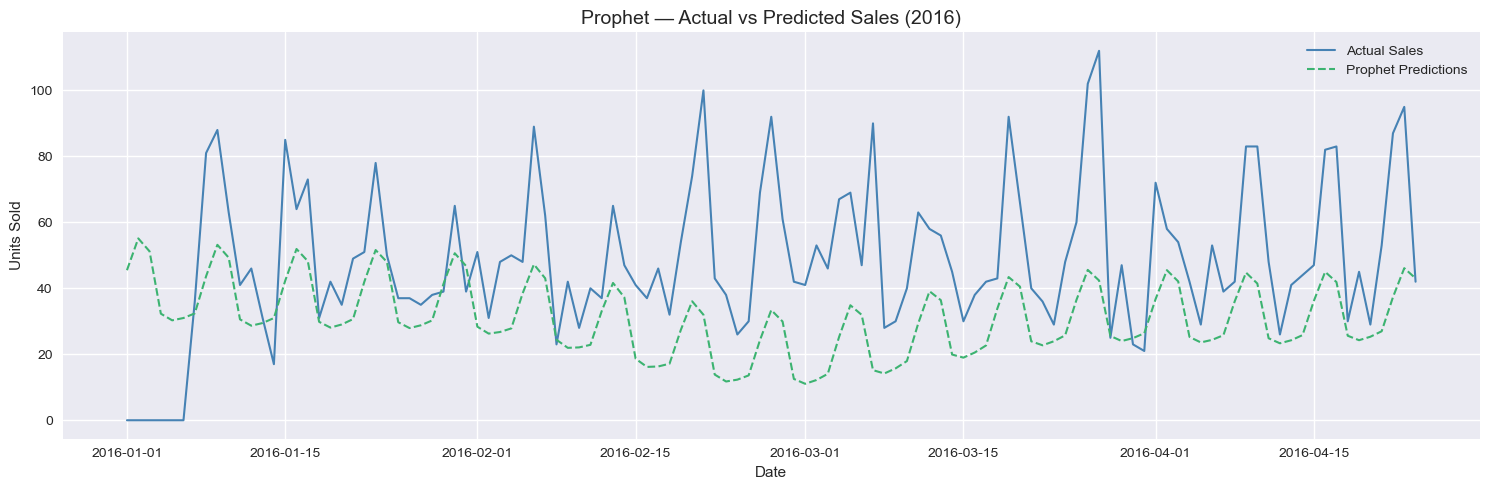

In [45]:
#4.5 Visualize Prophet Predictions

plt.figure(figsize=(15, 5))

# Plot actual sales
plt.plot(test['date'].values, y_test.values,
         color='steelblue', label='Actual Sales', linewidth=1.5)

# Plot predicted sales
plt.plot(test['date'].values, prophet_predictions,
         color='mediumseagreen', label='Prophet Predictions',
         linewidth=1.5, linestyle='--')

plt.title('Prophet — Actual vs Predicted Sales (2016)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

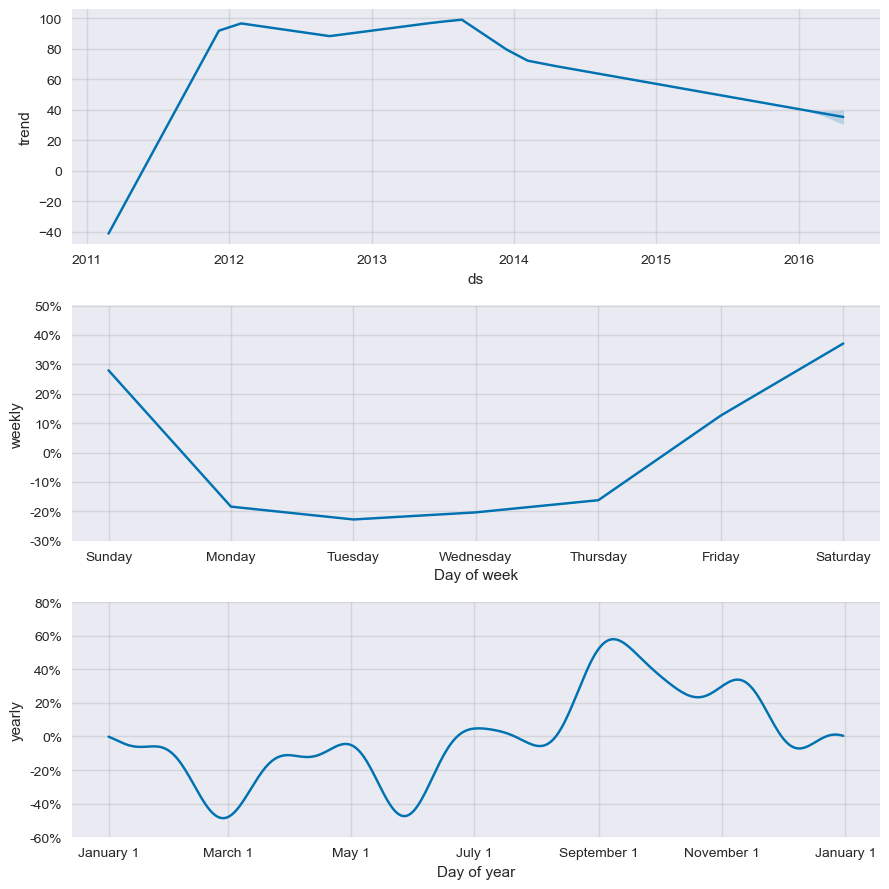

In [46]:
#4.6 Prophet Components Plot
fig = model_prophet.plot_components(forecast)
plt.tight_layout()
plt.show()

Prophet Components Analysis:
The components plot reveals three distinct patterns driving sales for FOODS_3_090:
Trend — this product followed a clear rise and fall lifecycle. Sales grew rapidly through 2012, stabilized through 2014, then declined through 2016. This suggests the product peaked in popularity around 2012-2014 and has been gradually losing market share since.

Weekly seasonality — Saturday and Sunday consistently drive 28-37% higher sales than average while weekdays see 15-22% below average sales. This confirms strong weekend shopping behavior at CA1 store.

Yearly seasonality — September is the strongest month at +60% above baseline, driven by back to school season. March and May show significant dips of around -45%, suggesting this product is less popular in spring months.

In [47]:
#C. SARIMA Model
# What is SARIMA?
# SARIMA stands for Seasonal AutoRegressive Integrated Moving Average.
# It's a classical statistics model that has been used for time series forecasting since the 1970s. It's the oldest and most traditional of our 3 models.

# Breaking Down the Name
# AR — AutoRegressive
# Uses past sales values to predict future ones. "Auto" means it regresses on itself — today's sales are predicted using yesterday's, last week's sales etc.
# I — Integrated
# Handles the trend by differencing the data — subtracting consecutive values to make the series stationary (flat, no trend).
# MA — Moving Average
# Uses past forecast errors to improve predictions. If the model was consistently wrong in a certain direction, MA corrects for that.
# S — Seasonal
# All of the above but applied to seasonal patterns too — weekly, monthly cycles.

In [48]:
#C 4.1 Import SARIMA

from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

print("SARIMA imported successfully!")

SARIMA imported successfully!


In [49]:
#4.2 Prepare Data for SARIMA
# SARIMA only needs the sales values as a time series
train_sarima = train.set_index('date')['sales']
test_sarima = test.set_index('date')['sales']

print("Train SARIMA shape:", train_sarima.shape)
print("Test SARIMA shape:", test_sarima.shape)
train_sarima.head(5)

Train SARIMA shape: (1770,)
Test SARIMA shape: (115,)


date
2011-02-26    0
2011-02-27    0
2011-02-28    0
2011-03-01    0
2011-03-02    0
Name: sales, dtype: int64

In [50]:
#4.3 Train SARIMA Model

# Define SARIMA model
# Order (p,d,q) = (1,1,1) - AR, differencing, MA terms
# Seasonal order (P,D,Q,s) = (1,1,1,7) - seasonal terms with weekly period
model_sarima = SARIMAX(
    train_sarima,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Train the model
result_sarima = model_sarima.fit(disp=False)

print("SARIMA model training complete!")

SARIMA model training complete!


In [51]:
#4.4 Make Predictions with SARIMA
# Generate predictions for the test period
sarima_predictions = result_sarima.forecast(steps=115)

# Calculate MAE
sarima_mae = mean_absolute_error(y_test, sarima_predictions)

print("SARIMA MAE:", round(sarima_mae, 2))
print("This means on average our predictions are off by", round(sarima_mae, 2), "units per day")

SARIMA MAE: 56.48
This means on average our predictions are off by 56.48 units per day


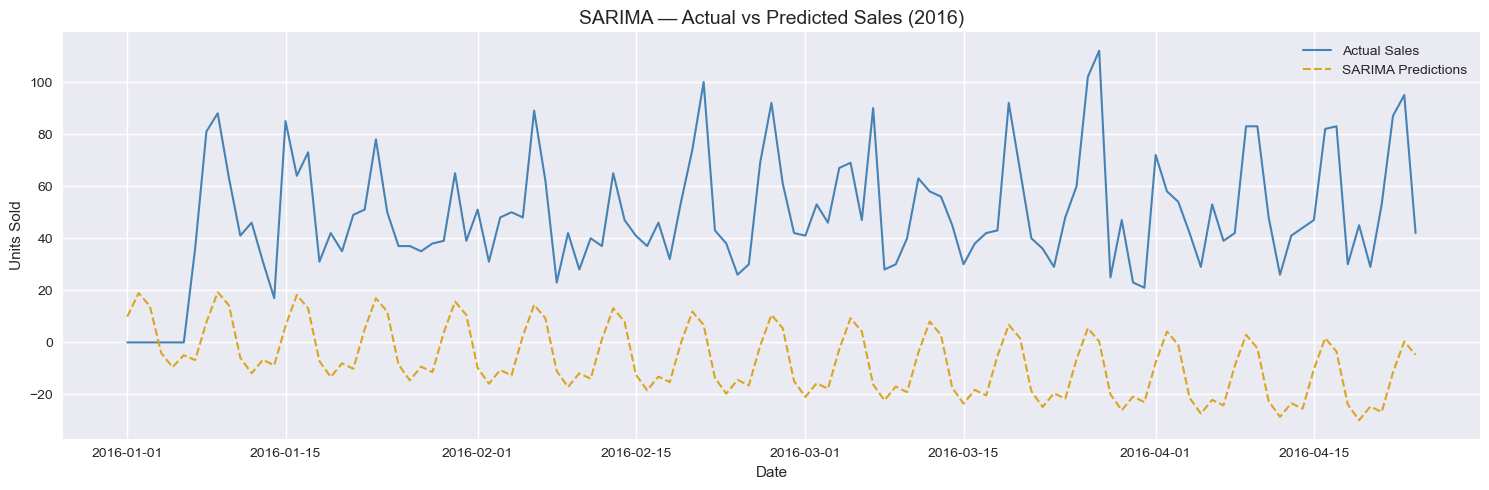

In [52]:
#4.5 Visualize SARIMA Predictions
plt.figure(figsize=(15, 5))

# Plot actual sales
plt.plot(test['date'].values, y_test.values,
         color='steelblue', label='Actual Sales', linewidth=1.5)

# Plot predicted sales
plt.plot(test['date'].values, sarima_predictions.values,
         color='goldenrod', label='SARIMA Predictions',
         linewidth=1.5, linestyle='--')

plt.title('SARIMA — Actual vs Predicted Sales (2016)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

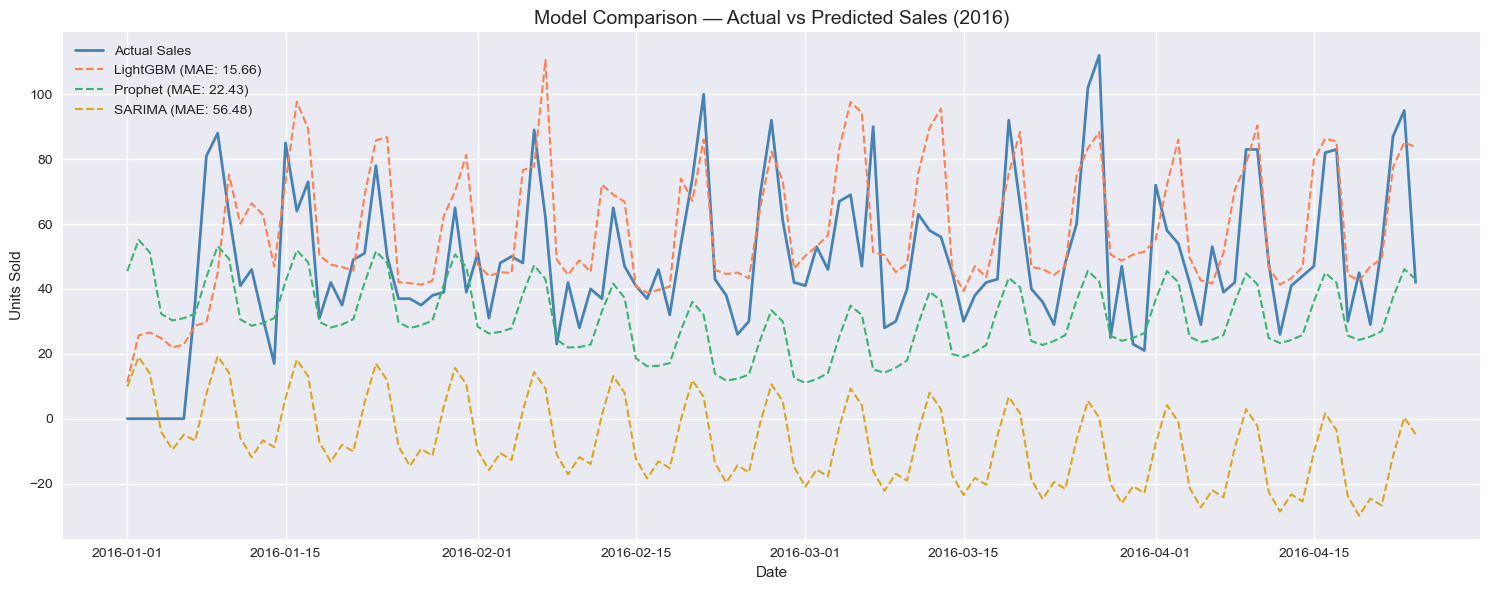

In [53]:
#4.6 Final Model Comparison Chart

plt.figure(figsize=(15, 6))

# Actual sales
plt.plot(test['date'].values, y_test.values,
         color='steelblue', label='Actual Sales', 
         linewidth=2)

# LightGBM
plt.plot(test['date'].values, lgb_predictions,
         color='coral', label=f'LightGBM (MAE: {round(lgb_mae, 2)})',
         linewidth=1.5, linestyle='--')

# Prophet
plt.plot(test['date'].values, prophet_predictions,
         color='mediumseagreen', label=f'Prophet (MAE: {round(prophet_mae, 2)})',
         linewidth=1.5, linestyle='--')

# SARIMA
plt.plot(test['date'].values, sarima_predictions.values,
         color='goldenrod', label=f'SARIMA (MAE: {round(sarima_mae, 2)})',
         linewidth=1.5, linestyle='--')

plt.title('Model Comparison — Actual vs Predicted Sales (2016)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

Model Comparison Summary:
Three models were built and evaluated on 115 days of unseen test data from 2016:

LightGBM achieved the best performance with an MAE of 15.66 units per day. Its ability to leverage all 19 engineered features — particularly rolling means and lag values — gave it a significant advantage over the other models.

Prophet performed reasonably well with an MAE of 22.43 despite using only date and sales data with zero manual feature engineering. Its automatic seasonality detection captured weekly and yearly patterns effectively.

SARIMA performed poorly with an MAE of 56.48. The model struggled with zero inflation in the sales data, trend reversal and the absence of external features like SNAP flags and price information. This confirms that classical statistical models are less suited for volatile retail demand data compared to modern ML approaches.

In [54]:
#Phase 5 — Evaluation

# What We'll Do in Phase 5
# 1. Multiple metrics — MAE alone isn't enough. We'll add:

# RMSE — penalizes large errors more heavily than MAE
# MAPE — error as a percentage, easy to explain to anyone

# 2. Residual analysis — checking if our model's errors are random or have a pattern. If errors have a pattern, the model is missing something.
# 3. Final comparison table — a clean summary table of all 3 models across all metrics
# 4. Best model conclusion — a written conclusion declaring the winner and why

In [55]:
#5.1 Calculate All Metrics for All Models

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    # Avoid division by zero in MAPE
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    
    print(f"\n{model_name} Performance:")
    print(f"  MAE  : {round(mae, 2)} units")
    print(f"  RMSE : {round(rmse, 2)} units")
    print(f"  MAPE : {round(mape, 2)}%")
    
    return {'model': model_name, 'MAE': round(mae, 2), 
            'RMSE': round(rmse, 2), 'MAPE': round(mape, 2)}

# Evaluate all 3 models
lgb_metrics = evaluate_model(y_test.values, lgb_predictions, 'LightGBM')
prophet_metrics = evaluate_model(y_test.values, prophet_predictions, 'Prophet')
sarima_metrics = evaluate_model(y_test.values, sarima_predictions.values, 'SARIMA')


LightGBM Performance:
  MAE  : 15.66 units
  RMSE : 19.8 units
  MAPE : 35.56%

Prophet Performance:
  MAE  : 22.43 units
  RMSE : 27.62 units
  MAPE : 38.56%

SARIMA Performance:
  MAE  : 56.48 units
  RMSE : 59.61 units
  MAPE : 124.11%


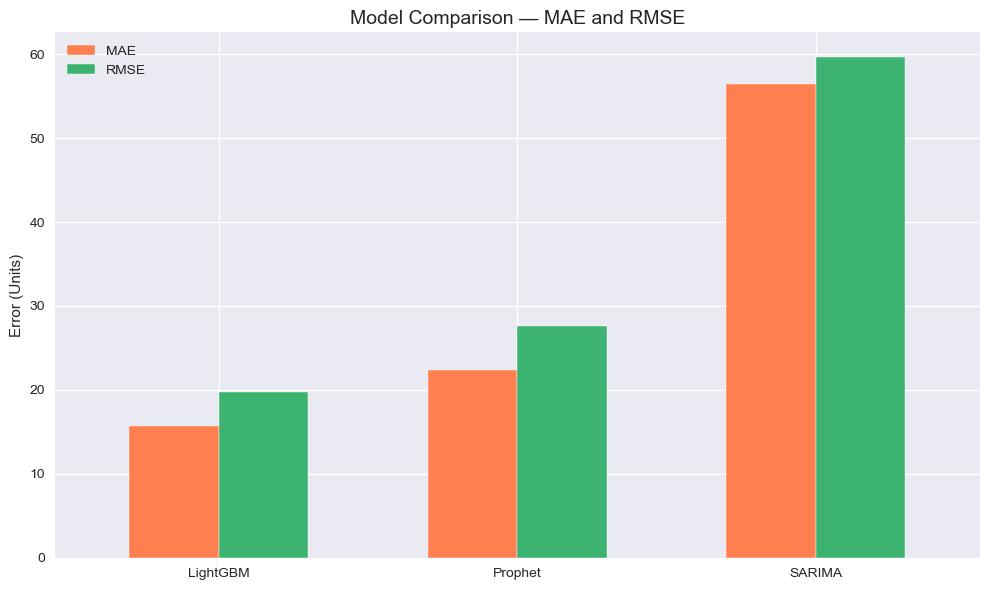


Full Results Table:
            MAE   RMSE    MAPE
model                         
LightGBM  15.66  19.80   35.56
Prophet   22.43  27.62   38.56
SARIMA    56.48  59.61  124.11


In [56]:
#5.2 Visual Comparison Table
import pandas as pd

# Create comparison dataframe
results_df = pd.DataFrame([lgb_metrics, prophet_metrics, sarima_metrics])
results_df = results_df.set_index('model')

# Plot as a bar chart
results_df[['MAE', 'RMSE']].plot(
    kind='bar',
    figsize=(10, 6),
    color=['coral', 'mediumseagreen'],
    edgecolor='white',
    width=0.6
)

plt.title('Model Comparison — MAE and RMSE', fontsize=14)
plt.xlabel('')
plt.ylabel('Error (Units)')
plt.xticks(rotation=0)
plt.legend(['MAE', 'RMSE'])
plt.tight_layout()
plt.show()

print("\nFull Results Table:")
print(results_df)

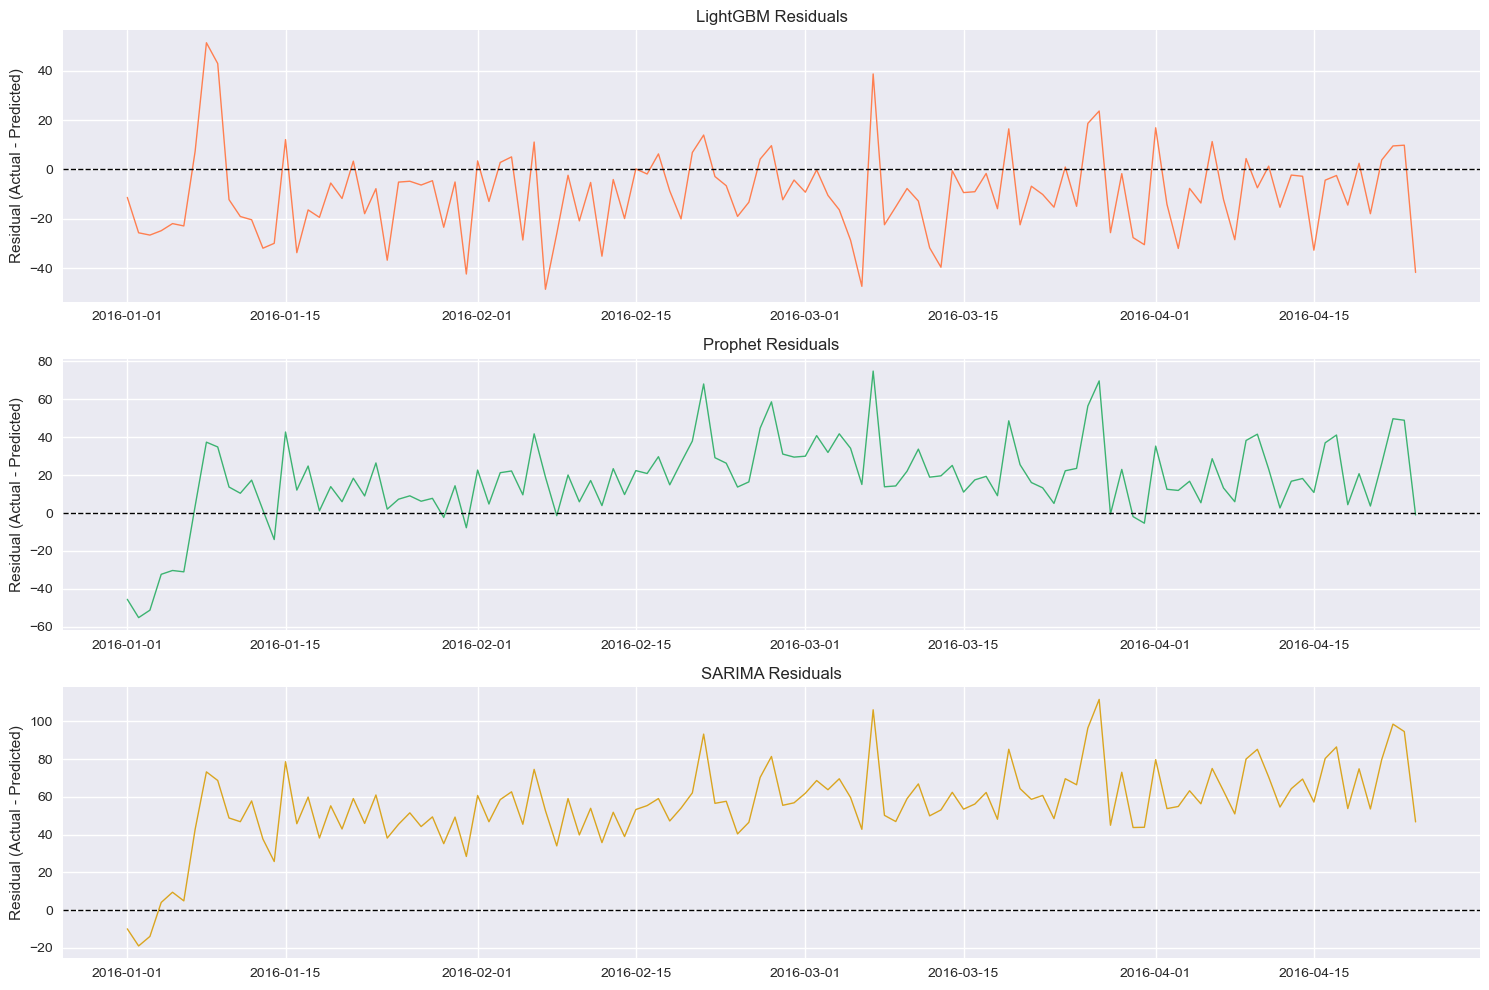

In [57]:
#5.3 Residual Analysis

# Calculate residuals (actual - predicted)
lgb_residuals = y_test.values - lgb_predictions
prophet_residuals = y_test.values - prophet_predictions
sarima_residuals = y_test.values - sarima_predictions.values

# Plot residuals
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# LightGBM residuals
axes[0].plot(test['date'].values, lgb_residuals, 
             color='coral', linewidth=1)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('LightGBM Residuals', fontsize=12)
axes[0].set_ylabel('Residual (Actual - Predicted)')

# Prophet residuals
axes[1].plot(test['date'].values, prophet_residuals,
             color='mediumseagreen', linewidth=1)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Prophet Residuals', fontsize=12)
axes[1].set_ylabel('Residual (Actual - Predicted)')

# SARIMA residuals
axes[2].plot(test['date'].values, sarima_residuals,
             color='goldenrod', linewidth=1)
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('SARIMA Residuals', fontsize=12)
axes[2].set_ylabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()

Residual Analysis:

Residual analysis reveals important behavioral differences between the three models:
LightGBM shows residuals closely scattered around zero with no clear systematic pattern. This indicates the model has no significant bias and its errors are largely random — the hallmark of a well fitted model.

Prophet shows residuals consistently above zero throughout the test period. This means Prophet systematically underestimates sales — it predicts lower than actual almost every day. This bias likely stems from the absence of lag features and rolling statistics which would have anchored predictions closer to recent demand levels.

SARIMA shows residuals far from zero throughout the entire test period confirming its poor performance. The large consistent errors indicate the model failed to capture the underlying demand patterns of this product.

In [58]:
#SAVING ALL THE TRAINED MODELS

import pickle
import os

# Create a models folder to store pickle files
os.makedirs('../app/models', exist_ok=True)

# Save LightGBM model
with open('../app/models/lgb_model.pkl', 'wb') as f:
    pickle.dump(model_lgb, f)

# Save Prophet model
with open('../app/models/prophet_model.pkl', 'wb') as f:
    pickle.dump(model_prophet, f)

# Save test data and predictions for the dashboard
with open('../app/models/test_data.pkl', 'wb') as f:
    pickle.dump({
        'test': test,
        'y_test': y_test,
        'lgb_predictions': lgb_predictions,
        'prophet_predictions': prophet_predictions,
        'train': train,
        'feature_cols': feature_cols
    }, f)

print("All models and data saved successfully!")

All models and data saved successfully!
